In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("categories.csv")

# Show first rows
df.head()

,catName,catId,pathCount,paths
0,Womens Beauty Accessories,Womens-Beauty-Accessories,2,"[""Beauty/Electrical/Spare-Parts-Accessories"",""..."
1,Men's Lip Balm,Mens-Lip-Balm,1,"[""Men/Skincare""]"
2,Lip care,Lip-care,2,"[""Beauty/Make-up/Lips"",""Beauty/Skincare""]"
3,Bottom wipers,Bottom-wipers,1,"[""Pharmacy-Health/Health-shop/Mobility-daily-l..."
4,Healthy Scalp,Healthy-Scalp,1,"[""Toiletries/Hair""]"


In [5]:
df["text"] = df["catName"].astype(str) + " " + df["paths"].astype(str)
texts = df["text"]

In [6]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=2000
)

X = vectorizer.fit_transform(texts)

In [7]:
num_clusters = 5

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

In [8]:
df[[text_column, "cluster"]].head(10)

,text,cluster
0,"Womens Beauty Accessories [""Beauty/Electrical/...",0
1,"Men's Lip Balm [""Men/Skincare""]",0
2,"Lip care [""Beauty/Make-up/Lips"",""Beauty/Skinca...",2
3,"Bottom wipers [""Pharmacy-Health/Health-shop/Mo...",4
4,"Healthy Scalp [""Toiletries/Hair""]",0
5,"Oil control [""Beauty/Premium-Beauty/Premium-me...",2
6,"Ulcers [""Pharmacy-Health/Health-shop/Mouth-care""]",4
7,"SPF 35+ [""Beauty/Premium-Beauty/Bath-body/Sun-...",2
8,"Travel health [""Pharmacy-Health/Health-shop""]",4
9,"Photo Mugs [""Photo/Photo-Printing"",""Photo/Albu...",0


In [9]:
terms = vectorizer.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(num_clusters):
    print(f"\nCluster {i} top words:")
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_words))


Cluster 0 top words:
hair, toiletries, electrical, photo, offers, men, beauty, styling, cameras, accessories

Cluster 1 top words:
toys, gift, gifts, age, school, pre, type, occasion, personalised, outdoor

Cluster 2 top words:
beauty, make, skincare, premium, accessories, face, nails, tips, inspiration, bath

Cluster 3 top words:
fragrance, beauty, aftershave, sets, perfume, gift, luxury, celebrity, offers, men

Cluster 4 top words:
health, pharmacy, shop, opticians, supplements, vitamins, services, aids, care, mobility


In [10]:
pca = PCA(n_components=2)
X_dense = X.toarray()
reduced = pca.fit_transform(X_dense)

df["x"] = reduced[:, 0]
df["y"] = reduced[:, 1]

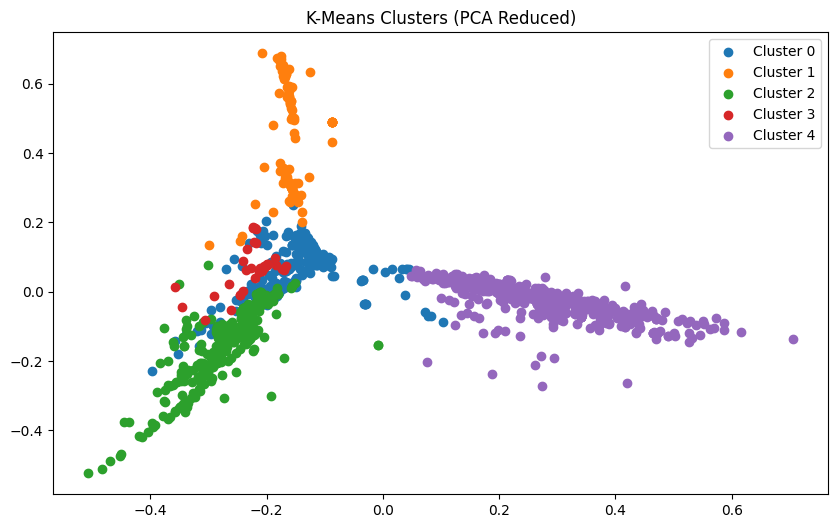

In [11]:
plt.figure(figsize=(10, 6))

for cluster in range(num_clusters):
    cluster_data = df[df["cluster"] == cluster]
    plt.scatter(cluster_data["x"], cluster_data["y"], label=f"Cluster {cluster}")

plt.legend()
plt.title("K-Means Clusters (PCA Reduced)")
plt.show()